# Project 1: A ReAct Tool-Using Agent (Groq + LangGraph)

This notebook builds the same agent as `agent.py` / `main.py`, but step by step so you can run each tool on its own before wiring them into the full graph.

**What a ReAct agent is:** ReAct stands for **Rea**son + **Act**. Instead of the LLM answering directly, it can:
1. **Reason** about what it needs to answer the question,
2. **Act** by calling a tool if it needs external information or computation,
3. **Observe** the tool's result,
4. Repeat steps 1-3 until it has enough information, then give a final answer.

See `../README.md` for the full architecture writeup - this notebook focuses on running the code.

## 1. Install dependencies

(Skip this cell if you already ran `pip install -r ../requirements.txt` in your terminal / virtual environment.)

In [ ]:
%pip install -r ../requirements.txt

## 2. Load secrets from `.env`

Both API keys live in the `.env` file at the repo root (never hardcoded in code - see `config.py` for why). `config.py` also validates both keys are present and raises a clear error if not.

In [1]:
import config

print("GROQ_API_KEY loaded:", bool(config.GROQ_API_KEY))
print("TAVILY_API_KEY loaded:", bool(config.TAVILY_API_KEY))
print("Model:", config.MODEL_NAME)

GROQ_API_KEY loaded: True
TAVILY_API_KEY loaded: True
Model: openai/gpt-oss-120b


## 3. Look at the tools individually

Before handing tools to an LLM, it's worth calling them yourself so you know exactly what they return - that's what the model will see as the "observation" after each tool call.

In [2]:
from tools import TOOLS, calculator, wikipedia_lookup, web_search

# .invoke() is how you call a LangChain tool directly (bypassing an LLM),
# using the same interface the agent will use internally.
print(calculator.invoke({"expression": "340 * 0.15"}))

C:\Users\omeza\AppData\Roaming\Python\Python314\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


51.0


In [3]:
print(wikipedia_lookup.invoke({"query": "Telangana"}))

Telangana is a state in southern India on the Deccan Plateau bordering Maharashtra and Chhattisgarh to the north and Andhra Pradesh and Karnataka to the south. It is the eleventh largest and the twelfth most populated state of India. According to the Rigveda's Aitareya Brahmana, the region corresponding to Telangana has been inhabited by the Asmakas and Andhras since at least the 8th and 9th century BCE, respectively, with the later Satavahana dynasty, who ruled over the entire Deccan Plateau, establishing trade relations as far as the Roman Empire.


In [ ]:
print(web_search.invoke({"query": "Election commisioin of India latest news"}))

{'query': 'Election commisioin of India latest news', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.thehindu.com/topic/election-commission-of-india', 'title': 'Latest Election Commission of India News, Photos, Latest News Headlines about Election Commission of India-The Hindu', 'content': "### ECI calls both factions of Trinamool for hearing on September 17\n\nThe Hindu Bureau\n\nUnion Home Minister Amit Shah releasing the BJP's manifesto for the upcoming West Bengal Assembly elections 2026 in Kolkata.\n\n### SC agrees to hear a plea for standard format for election manifestos\n\nThe Hindu Bureau\n\nTrinamool Congress leader Mamata Banerjee. File\n\n### ECI gives Mamata, Ritabrata more time to submit documents in Trinamool symbol dispute\n\nThe Hindu Bureau [...] ### Youth power, an electoral force still in the making\n\nAkshay Rout\n\nTamil Nadu Chief Minister Jayalalitha in Ranipet on August 2, 1993.\n\n### When the Election Commission ca

In [13]:
# Each tool has a name and description - this is literally what gets sent to
# the LLM so it can decide which tool to call and when.
for t in TOOLS:
    print(f"- {t.name}: {t.description}\n")

- calculator: Evaluate an arithmetic expression and return the numeric result.

Use this for ANY math - addition, subtraction, multiplication, division,
powers, percentages written as arithmetic, etc. Do not compute math
yourself; call this tool instead, since LLMs are unreliable at arithmetic.

Args:
    expression: A plain arithmetic expression, e.g. "12 * (4 + 3)" or
        "340 * 0.15". Supports + - * / % ** and parentheses only.

- wikipedia_lookup: Look up a concise factual summary of a topic, person, place, or event on Wikipedia.

Best for stable background knowledge (biographies, historical facts,
definitions, geography). Not useful for anything that changes day to day -
use web_search for that instead.

Args:
    query: A short search term, e.g. "Marie Curie" or "Great Barrier Reef".

- web_search: A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippe

## 4. Build the LangGraph agent

This reuses everything defined in `agent.py`. Read that file alongside this section - the important pieces are:

- **State**: `messages`, a growing list of the whole conversation (system prompt, human turns, AI replies, tool results).
- **`agent` node**: calls the LLM (bound to the tools) with the current message list. The LLM either answers directly or asks to call a tool.
- **`tools` node**: LangGraph's prebuilt `ToolNode` actually executes whichever tool(s) the model asked for, and appends the results back into `messages`.
- **Conditional edge**: after the `agent` node runs, `should_continue` checks whether the model's last message requested a tool call. If yes, go to `tools`; if no, stop.
- **Loop**: `tools` always routes back to `agent`, so the model gets to see tool results and reason again - possibly calling more tools - until it's ready to answer.

In [14]:
from agent import build_agent_graph

app = build_agent_graph()

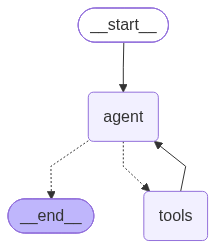

In [15]:
app

### Visualize the graph

`get_graph().draw_mermaid()` prints Mermaid diagram syntax (no extra packages or network access needed) that you can paste into https://mermaid.live to see the graph shape: `START -> agent -> (tools -> agent)* -> END`.

In [16]:
print(app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 5. Run the agent and watch each step

We use `app.stream(..., stream_mode="values")` instead of `app.invoke(...)` so we can print every intermediate step - which tool got called, with what arguments, and what it returned - instead of only the final answer. This is the best way to build intuition for what the agent is actually deciding.

In [17]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage

from agent import SYSTEM_PROMPT


def ask(question: str):
    messages = [SystemMessage(content=SYSTEM_PROMPT), HumanMessage(content=question)]
    print(f"You: {question}\n")

    for step in app.stream({"messages": messages}, stream_mode="values"):
        last_message = step["messages"][-1]

        if isinstance(last_message, AIMessage) and last_message.tool_calls:
            for call in last_message.tool_calls:
                print(f"  -> calling tool: {call['name']}({call['args']})")
        elif isinstance(last_message, ToolMessage):
            preview = str(last_message.content)[:200]
            print(f"  <- {last_message.name} returned: {preview}")
        elif isinstance(last_message, AIMessage) and last_message.content:
            print(f"\nAgent: {last_message.content}\n")

### Example 1: no tool needed

General knowledge the model is already confident about - watch it answer directly without any tool calls.

In [18]:
ask("What language is primarily used with the LangChain framework?")

You: What language is primarily used with the LangChain framework?




Agent: The LangChain framework is primarily used with **Python**. While there are SDKs for other languages (e.g., JavaScript/TypeScript), the core and most widely‑adopted implementation of LangChain is written in Python.



### Example 2: calculator

In [19]:
ask("If I invest 12000 rupees at 7.5% simple annual interest, how much interest do I earn in 3 years?")

You: If I invest 12000 rupees at 7.5% simple annual interest, how much interest do I earn in 3 years?

  -> calling tool: calculator({'expression': '12000 * 0.075 * 3'})
  <- calculator returned: 2700.0

Agent: The simple‑interest earned is  

\[
\text{Interest} = P \times r \times t = 12{,}000 \times 0.075 \times 3 = 2{,}700 \text{ rupees}.
\]

So you would earn **₹2,700** in interest over 3 years.



### Example 3: Wikipedia lookup

In [20]:
ask("Who was Ada Lovelace and why is she significant in computing history?")

You: Who was Ada Lovelace and why is she significant in computing history?

  -> calling tool: wikipedia_lookup({'query': 'Ada Lovelace'})
  <- wikipedia_lookup returned: Wikipedia lookup failed: Expecting value: line 1 column 1 (char 0)
  -> calling tool: wikipedia_lookup({'query': 'Ada Lovelace biography'})
  <- wikipedia_lookup returned: Wikipedia lookup failed: Expecting value: line 1 column 1 (char 0)
  -> calling tool: wikipedia_lookup({'query': 'Ada Lovelace'})
  <- wikipedia_lookup returned: Wikipedia lookup failed: Expecting value: line 1 column 1 (char 0)
  -> calling tool: web_search({'query': 'Ada Lovelace significance in computing history', 'recency_days': -1, 'search_depth': 'fast', 'topn': 5})
  <- web_search returned: {"query": "Ada Lovelace significance in computing history", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.academia.edu/118873086/Ada_Lovelace_s_Legacy_for

Agent: **Ada Lovelace (1815‑1852)** was an English mat

### Example 4: live web search

In [24]:
ask("Tell me about Election commisioin of India latest news today on sep 22, 2026")

You: Tell me about Election commisioin of India latest news today on sep 22, 2026

  -> calling tool: web_search({'end_date': '2026-09-22', 'query': 'Election Commission of India September 22 2026 news', 'start_date': '2026-09-22', 'time_range': 'day', 'topic': 'news'})
  <- web_search returned: {'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}
  -> calling tool: web_search({'end_date': '2026-09-22', 'query': 'Election Commission of India September 22 2026', 'start_date': '2026-09-22'})
  <- web_search returned: {'error': ValueError('Error 400: start_date and end_date cannot be the same')}
  -> calling tool: web_search({'query': 'Election Commission of India Sep 22 2026', 'time_range': 'day', 'topic': 'news'})
  <- web_search returned: {"query": "Election Commission of India Sep 22 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/p/DdoUS_PFPK9", "title": "Instagram", "c

Agent

### Example 5: multi-tool reasoning

A question that needs more than one tool in sequence - watch the agent loop through `agent -> tools -> agent` more than once.

In [25]:
ask("What is the population of Japan according to Wikipedia, and what is 15% of that number?")

You: What is the population of Japan according to Wikipedia, and what is 15% of that number?

  -> calling tool: wikipedia_lookup({'query': 'Japan population'})
  <- wikipedia_lookup returned: The demography of Japan is monitored by the National Institute of Population and Social Security Research (IPSS) and Statistics Bureau. In April 2025, Japan's population was roughly 123.4 million peop
  -> calling tool: calculator({'expression': '123.4e6 * 0.15'})
  <- calculator returned: 18510000.0

Agent: According to Wikipedia, Japan’s population is about **123.4 million people** (as of April 2025).  

15 % of that figure is:

\[
123.4\text{ million} \times 0.15 = 18.51\text{ million}
\]

So **15 % of Japan’s population is roughly 18.5 million people**.



## 6. Key takeaways

- An agent is just an LLM call wrapped in a **loop with a decision point** ("do I need a tool, or am I done?").
- The LLM never executes anything itself - it only *requests* a tool call; your code (`ToolNode`) actually runs it and feeds the result back in.
- Tool **descriptions are prompts**. The model's tool choice is only as good as how clearly you describe what each tool is for.
- This agent has **no memory across separate runs** of the notebook/CLI - each new `python main.py` session starts fresh, and even within one session, closing it loses the conversation. That's intentional for Project 1; persistent memory (LangGraph checkpointers) is a natural next project.

For the full architecture explanation (why LangGraph over a plain LangChain `AgentExecutor`, why the state is shaped this way, security notes on tool design, and ideas for extending this project), see `README.md` in this folder.